# UAS ML REGRESSION

Haikal Ali 1103223071 TK46GAB

# Hands-on End-to-End Models Machine Learning dan Deep Learning
## Regresi Prediksi Tahun Rilis Lagu

Notebook ini membangun pipeline regresi end-to-end untuk memprediksi **tahun rilis lagu** berdasarkan fitur numerik audio.

Dataset yang digunakan: `midterm-regresi-dataset.csv`.

Karakteristik dataset:

- Kolom pertama adalah target: `year`.
- Kolom lainnya adalah fitur numerik audio.
- Dataset tidak memiliki nama kolom asli.
- Karena itu, file harus dibaca dengan `header=None`.
- Target berbentuk tahun rilis lagu, misalnya `2001`, sehingga problem ini diperlakukan sebagai **regression problem**, bukan classification problem.

Model yang dibuat:

1. **Baseline model**: prediksi median tahun rilis.
2. **Machine Learning model**: `HistGradientBoostingRegressor`.
3. **Deep Learning model**: neural network MLP dengan TensorFlow/Keras.
4. **Hyperparameter tuning**: Optuna untuk mencari konfigurasi ML model yang lebih baik.
5. **Experiment tracking**: MLflow dengan SQLite backend.
6. **Model interpretation**: LIME untuk menjelaskan prediksi individual.

Notebook ini sengaja dibuat cukup hemat RAM agar masih realistis dijalankan di Google Colab Free.

## 1. Instalasi Library

Library tambahan yang dipakai:

- `optuna`: untuk hyperparameter tuning.
- `mlflow`: untuk mencatat parameter, metrik, model, dan artifact eksperimen.
- `lime`: untuk interpretasi lokal terhadap prediksi model.

Catatan: setelah instalasi, Colab kadang meminta restart runtime. Kalau muncul warning dependency tapi cell berikutnya tetap jalan, warning tersebut bisa diabaikan.

In [1]:
!pip install -q optuna mlflow lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 11.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 9.7 MB/s eta 0:00:00
   ━

In [2]:
!gdown --fuzzy "https://drive.google.com/file/d/1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9/view"

Downloading...
From (original): https://drive.google.com/uc?id=1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9
From (redirected): https://drive.google.com/uc?id=1f8eaAZY-7YgFxLcrL3OkvSRa3onNNLb9&confirm=t&uuid=17a1fe8d-2449-48c9-9ad9-216c97710f88
To: /content/midterm-regresi-dataset.csv
100% 443M/443M [00:12<00:00, 36.6MB/s]


## 2. Import Library

Bagian ini memuat library utama untuk:

- manipulasi data (`pandas`, `numpy`),
- visualisasi (`matplotlib`),
- preprocessing dan evaluasi (`scikit-learn`),
- machine learning model,
- deep learning model,
- tuning (`optuna`),
- tracking (`mlflow`),
- interpretasi (`lime`).

In [3]:
import json
import os
import random
import shutil
import warnings
from pathlib import Path

import joblib
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import mlflow.tensorflow
import numpy as np
import optuna
import pandas as pd
import tensorflow as tf

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

## 3. Konfigurasi Global

Semua pengaturan utama dikumpulkan di satu tempat agar mudah diubah.

Beberapa parameter penting:

- `DATA_PATH`: lokasi file CSV.
- `RANDOM_STATE`: seed agar hasil split dan training lebih reproducible.
- `MISSING_THRESHOLD`: fitur dengan missing value di atas threshold ini akan dibuang.
- `CLIP_LOWER_Q` dan `CLIP_UPPER_Q`: batas quantile untuk clipping outlier.
- `N_OPTUNA_TRIALS`: jumlah percobaan Optuna. Nilai kecil dipakai agar aman di Colab Free.
- `DL_EPOCHS`: jumlah epoch deep learning. Early stopping tetap digunakan agar training berhenti jika validation loss tidak membaik.

Kalau runtime Colab lambat, kurangi `N_OPTUNA_TRIALS`, `ML_MAX_ITER`, atau `DL_EPOCHS`.

In [4]:
CONFIG = {
  "DATA_PATH": "/content/midterm-regresi-dataset.csv",
  "ARTIFACT_DIR": "/content/song_year_artifacts",
  "RANDOM_STATE": 42,
  "TEST_SIZE": 0.15,
  "VAL_SIZE": 0.15,
  "MISSING_THRESHOLD": 0.40,
  "CLIP_LOWER_Q": 0.01,
  "CLIP_UPPER_Q": 0.99,
  "N_OPTUNA_TRIALS": 10,
  "OPTUNA_TRAIN_SAMPLE": 120000,
  "OPTUNA_VAL_SAMPLE": 40000,
  "ML_MAX_ITER": 250,
  "DL_EPOCHS": 40,
  "DL_BATCH_SIZE": 512,
  "LIME_SAMPLE_SIZE": 5000
}

np.random.seed(CONFIG["RANDOM_STATE"])
random.seed(CONFIG["RANDOM_STATE"])
tf.random.set_seed(CONFIG["RANDOM_STATE"])

Path(CONFIG["ARTIFACT_DIR"]).mkdir(parents=True, exist_ok=True)
CONFIG

{'DATA_PATH': '/content/midterm-regresi-dataset.csv',
 'ARTIFACT_DIR': '/content/song_year_artifacts',
 'RANDOM_STATE': 42,
 'TEST_SIZE': 0.15,
 'VAL_SIZE': 0.15,
 'MISSING_THRESHOLD': 0.4,
 'CLIP_LOWER_Q': 0.01,
 'CLIP_UPPER_Q': 0.99,
 'N_OPTUNA_TRIALS': 10,
 'OPTUNA_TRAIN_SAMPLE': 120000,
 'OPTUNA_VAL_SAMPLE': 40000,
 'ML_MAX_ITER': 250,
 'DL_EPOCHS': 40,
 'DL_BATCH_SIZE': 512,
 'LIME_SAMPLE_SIZE': 5000}

## 4. Setup MLflow

MLflow dipakai untuk mencatat workflow eksperimen.

Di versi MLflow terbaru, filesystem backend seperti `file:/content/mlruns` dapat memunculkan error karena backend tersebut masuk maintenance mode. Karena itu, notebook ini memakai **SQLite backend**:

```text
sqlite:////content/mlflow_song_year.db
```

Artifact seperti model dan file metrik disimpan ke folder lokal Colab.

In [5]:
MLFLOW_DB_PATH = "/content/mlflow_song_year.db"
MLFLOW_ARTIFACT_ROOT = "/content/mlflow_song_year_artifacts"
EXPERIMENT_NAME = "song_year_regression_ml_dl"

Path(MLFLOW_ARTIFACT_ROOT).mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH}")

experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
if experiment is None:
  mlflow.create_experiment(
    name=EXPERIMENT_NAME,
    artifact_location=f"file://{MLFLOW_ARTIFACT_ROOT}"
  )

mlflow.set_experiment(EXPERIMENT_NAME)

print("MLflow tracking URI:", mlflow.get_tracking_uri())
print("Experiment name:", EXPERIMENT_NAME)
print("Artifact root:", MLFLOW_ARTIFACT_ROOT)

2026/06/17 11:56:42 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/17 11:56:42 INFO mlflow.store.db.utils: Updating database tables


MLflow tracking URI: sqlite:////content/mlflow_song_year.db
Experiment name: song_year_regression_ml_dl
Artifact root: /content/mlflow_song_year_artifacts


## 5. Load Dataset dan Perbaikan Header

Dataset ini **tidak memiliki header**.

Kalau dibaca dengan kode biasa:

```python
df = pd.read_csv("midterm-regresi-dataset.csv")
```

maka baris pertama akan dianggap sebagai nama kolom. Itu salah, karena angka `2001`, `49.94357`, dan seterusnya sebenarnya adalah data.

Solusi yang benar:

```python
df = pd.read_csv(path, header=None)
```

Setelah itu kolom diberi nama manual:

- `year` untuk target,
- `feature_1`, `feature_2`, ..., untuk fitur audio.

In [6]:
data_path = Path(CONFIG["DATA_PATH"])

if not data_path.exists():
  raise FileNotFoundError(
    f"File tidak ditemukan: {data_path}\n"
    "Upload file midterm-regresi-dataset.csv ke /content atau ubah CONFIG['DATA_PATH']."
  )

# Penting: header=None supaya baris pertama tidak berubah menjadi nama kolom.
df = pd.read_csv(data_path, header=None)

# Konversi semua kolom ke numerik. Kalau ada baris header palsu, nilainya menjadi NaN dan bisa dibersihkan.
df = df.apply(pd.to_numeric, errors="coerce")

# Rename kolom.
df.columns = ["year"] + [f"feature_{i}" for i in range(1, df.shape[1])]

print("Shape dataset:", df.shape)
df.head()

Shape dataset: (515345, 91)


,year,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_81,feature_82,feature_83,feature_84,feature_85,feature_86,feature_87,feature_88,feature_89,feature_90
0,2001,49.94357,21.47114,73.07750,8.74861,-17.40628,-13.09905,-25.01202,-12.23257,7.83089,...,13.01620,-54.40548,58.99367,15.37344,1.11144,-23.08793,68.40795,-1.82223,-27.46348,2.26327
1,2001,48.73215,18.42930,70.32679,12.94636,-10.32437,-24.83777,8.76630,-0.92019,18.76548,...,5.66812,-19.68073,33.04964,42.87836,-9.90378,-32.22788,70.49388,12.04941,58.43453,26.92061
2,2001,50.95714,31.85602,55.81851,13.41693,-6.57898,-18.54940,-3.27872,-2.35035,16.07017,...,3.03800,26.05866,-50.92779,10.93792,-0.07568,43.20130,-115.00698,-0.05859,39.67068,-0.66345
3,2001,48.24750,-1.89837,36.29772,2.58776,0.97170,-26.21683,5.05097,-10.34124,3.55005,...,34.57337,-171.70734,-16.96705,-46.67617,-12.51516,82.58061,-72.08993,9.90558,199.62971,18.85382
4,2001,50.97020,42.20998,67.09964,8.46791,-15.85279,-16.81409,-12.48207,-9.37636,12.63699,...,9.92661,-55.95724,64.92712,-17.72522,-1.49237,-7.50035,51.76631,7.88713,55.66926,28.74903


## 6. Validasi Awal Dataset

Pada tahap ini kita memeriksa:

- jumlah baris dan kolom,
- tipe data,
- apakah target `year` terbaca benar,
- rentang tahun,
- jumlah missing value.

Validasi ini penting karena error preprocessing sering berasal dari cara baca CSV yang salah, terutama pada dataset tanpa header.

In [7]:
print("Informasi dataset:")
print(df.info())

print("\nStatistik target year:")
display(df["year"].describe())

print("\nJumlah missing value total:", int(df.isna().sum().sum()))
print("Missing value pada target year:", int(df["year"].isna().sum()))

Informasi dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515345 entries, 0 to 515344
Data columns (total 91 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   year        515345 non-null  int64  
 1   feature_1   515345 non-null  float64
 2   feature_2   515345 non-null  float64
 3   feature_3   515345 non-null  float64
 4   feature_4   515345 non-null  float64
 5   feature_5   515345 non-null  float64
 6   feature_6   515345 non-null  float64
 7   feature_7   515345 non-null  float64
 8   feature_8   515345 non-null  float64
 9   feature_9   515345 non-null  float64
 10  feature_10  515345 non-null  float64
 11  feature_11  515345 non-null  float64
 12  feature_12  515345 non-null  float64
 13  feature_13  515345 non-null  float64
 14  feature_14  515345 non-null  float64
 15  feature_15  515345 non-null  float64
 16  feature_16  515345 non-null  float64
 17  feature_17  515345 non-null  float64
 18  feature_18  515345 non-nu

,year
count,515345.000000
mean,1998.397082
std,10.931046
min,1922.000000
25%,1994.000000
50%,2002.000000
75%,2006.000000
max,2011.000000



Jumlah missing value total: 0
Missing value pada target year: 0


## 7. Cleaning Target

Target `year` harus valid karena model belajar dari target tersebut.

Langkah cleaning target:

1. Hapus baris dengan target kosong.
2. Pastikan `year` berada pada rentang masuk akal.
3. Simpan target sebagai nilai numerik.

Untuk dataset lagu modern, tahun biasanya berada di sekitar 1920 sampai 2011. Namun batas dibuat sedikit fleksibel agar tidak terlalu agresif membuang data.

In [8]:
before_rows = len(df)

# Hapus baris dengan target kosong.
df = df.dropna(subset=["year"]).copy()

# Filter rentang tahun yang masuk akal.
df = df[(df["year"] >= 1900) & (df["year"] <= 2025)].copy()

after_rows = len(df)
print("Baris sebelum cleaning target:", before_rows)
print("Baris sesudah cleaning target:", after_rows)
print("Baris terhapus:", before_rows - after_rows)

# Agar hemat RAM.
df["year"] = df["year"].astype(np.float32)

Baris sebelum cleaning target: 515345
Baris sesudah cleaning target: 515345
Baris terhapus: 0


## 8. Exploratory Data Analysis Singkat

EDA dilakukan untuk memahami distribusi target.

Hal yang diperhatikan:

- Apakah tahun rilis tersebar merata?
- Apakah terdapat dominasi tahun tertentu?
- Apakah target terlihat skewed?

Pada regresi, distribusi target berpengaruh terhadap interpretasi metrik. Misalnya, kalau banyak lagu berasal dari tahun 1990-an dan 2000-an, model bisa terlihat cukup baik hanya dengan menebak dekat area tersebut.

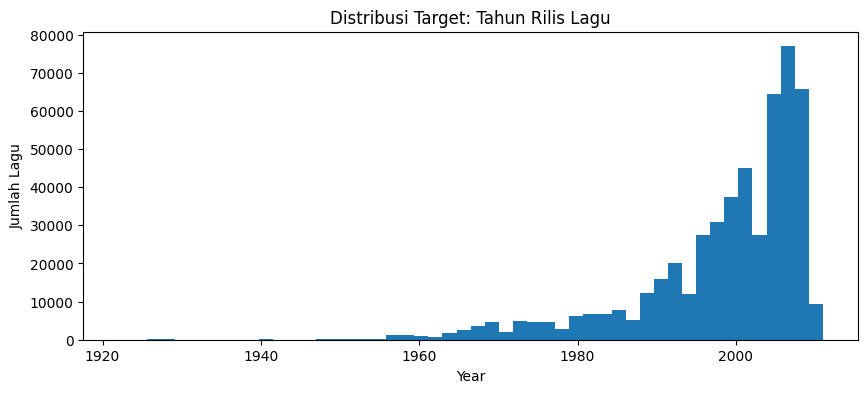

Jumlah tahun unik: 89
Tahun minimum: 1922
Tahun maksimum: 2011


In [9]:
plt.figure(figsize=(10, 4))
plt.hist(df["year"], bins=50)
plt.title("Distribusi Target: Tahun Rilis Lagu")
plt.xlabel("Year")
plt.ylabel("Jumlah Lagu")
plt.show()

print("Jumlah tahun unik:", df["year"].nunique())
print("Tahun minimum:", int(df["year"].min()))
print("Tahun maksimum:", int(df["year"].max()))

## 9. Pisahkan Target dan Fitur

Target yang diprediksi adalah `year`.

Semua kolom selain `year` diperlakukan sebagai fitur numerik audio.

Karena nama fitur asli tidak tersedia, fitur diberi nama generik seperti `feature_1`, `feature_2`, dan seterusnya. Ini berarti interpretasi domainnya terbatas, tetapi model tetap bisa belajar pola statistik dari fitur tersebut.

In [10]:
target_col = "year"
feature_cols = [col for col in df.columns if col != target_col]

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Jumlah fitur awal:", len(feature_cols))
print("Shape X:", X.shape)
print("Shape y:", y.shape)

Jumlah fitur awal: 90
Shape X: (515345, 90)
Shape y: (515345,)


## 10. Missing Value Analysis dan Feature Selection Awal

Fitur dengan missing value terlalu tinggi bisa membuat preprocessing berat dan informasinya kurang stabil.

Strategi:

- Hitung persentase missing value tiap fitur.
- Buang fitur dengan missing ratio di atas `MISSING_THRESHOLD`.
- Missing value tersisa akan diisi dengan median dari training set.

Median lebih aman daripada mean karena lebih tahan terhadap outlier.

In [11]:
missing_ratio = X.isna().mean().sort_values(ascending=False)

print("Top 10 fitur dengan missing ratio tertinggi:")
display(missing_ratio.head(10).to_frame("missing_ratio"))

selected_features = missing_ratio[missing_ratio <= CONFIG["MISSING_THRESHOLD"]].index.tolist()
removed_missing_features = [col for col in feature_cols if col not in selected_features]

X = X[selected_features].copy()
feature_cols = selected_features

print("Jumlah fitur setelah missing filter:", len(feature_cols))
print("Jumlah fitur dibuang karena missing tinggi:", len(removed_missing_features))

Top 10 fitur dengan missing ratio tertinggi:


,missing_ratio
feature_1,0.0
feature_2,0.0
feature_3,0.0
feature_4,0.0
feature_5,0.0
feature_6,0.0
feature_7,0.0
feature_8,0.0
feature_9,0.0
feature_10,0.0


Jumlah fitur setelah missing filter: 90
Jumlah fitur dibuang karena missing tinggi: 0


## 11. Hapus Fitur Konstan atau Hampir Konstan

Fitur yang nilainya sama untuk semua baris tidak membantu model karena tidak memiliki variasi.

Fitur seperti ini hanya menambah beban komputasi tanpa memberi informasi prediktif.

In [12]:
nunique = X.nunique(dropna=True)
constant_features = nunique[nunique <= 1].index.tolist()

if constant_features:
  X = X.drop(columns=constant_features)
  feature_cols = [col for col in feature_cols if col not in constant_features]

print("Jumlah fitur konstan/hampir konstan yang dibuang:", len(constant_features))
print("Jumlah fitur akhir sebelum split:", len(feature_cols))

Jumlah fitur konstan/hampir konstan yang dibuang: 0
Jumlah fitur akhir sebelum split: 90


## 12. Optimasi Tipe Data untuk Colab Free

Dataset numerik besar bisa menghabiskan RAM. Karena itu fitur dikonversi ke `float32`.

`float32` biasanya cukup untuk model ML/DL tabular dan jauh lebih hemat memori dibanding `float64`.

In [13]:
X = X.astype(np.float32)
y = y.astype(np.float32)

memory_mb = X.memory_usage(deep=True).sum() / 1024**2
print(f"Estimasi memory fitur setelah float32: {memory_mb:.2f} MB")

Estimasi memory fitur setelah float32: 176.93 MB


## 13. Train/Validation/Test Split

Dataset dibagi menjadi tiga bagian:

- **Training set**: untuk melatih model.
- **Validation set**: untuk memilih model dan tuning hyperparameter.
- **Test set**: untuk evaluasi akhir.

Test set tidak boleh dipakai saat tuning agar evaluasi akhir tetap fair.

In [14]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
  X,
  y,
  test_size=CONFIG["TEST_SIZE"],
  random_state=CONFIG["RANDOM_STATE"]
)

relative_val_size = CONFIG["VAL_SIZE"] / (1.0 - CONFIG["TEST_SIZE"])

X_train, X_val, y_train, y_val = train_test_split(
  X_train_val,
  y_train_val,
  test_size=relative_val_size,
  random_state=CONFIG["RANDOM_STATE"]
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (360741, 90)
Validation shape: (77302, 90)
Test shape: (77302, 90)


## 14. Outlier Handling dengan Quantile Clipping

Outlier adalah nilai ekstrem yang bisa membuat model terlalu fokus pada kasus langka.

Strategi yang digunakan:

- Hitung batas bawah dan atas dari training set saja.
- Gunakan quantile 1% dan 99%.
- Nilai di bawah batas bawah dinaikkan ke batas bawah.
- Nilai di atas batas atas diturunkan ke batas atas.

Kenapa batas dihitung dari training set saja?

Agar tidak terjadi **data leakage**. Validation dan test set harus dianggap sebagai data baru yang belum pernah dilihat model.

In [15]:
clip_lower = X_train.quantile(CONFIG["CLIP_LOWER_Q"])
clip_upper = X_train.quantile(CONFIG["CLIP_UPPER_Q"])

# Jika ada fitur dengan quantile bermasalah, fallback ke nilai min/max training.
clip_lower = clip_lower.fillna(X_train.min())
clip_upper = clip_upper.fillna(X_train.max())

def apply_clipping(data, lower, upper):
  clipped = data.clip(lower=lower, upper=upper, axis=1)
  return clipped.astype(np.float32)

X_train_clip = apply_clipping(X_train, clip_lower, clip_upper)
X_val_clip = apply_clipping(X_val, clip_lower, clip_upper)
X_test_clip = apply_clipping(X_test, clip_lower, clip_upper)

print("Clipping selesai.")
print("Contoh batas clipping:")
display(pd.DataFrame({
  "lower": clip_lower.head(10),
  "upper": clip_upper.head(10)
}))

Clipping selesai.
Contoh batas clipping:


,lower,upper
feature_1,25.253614,53.264851
feature_2,-157.708682,98.818314
feature_3,-85.807443,96.962947
feature_4,-33.904742,53.340890
feature_5,-63.554625,50.424069
feature_6,-33.284528,28.799407
feature_7,-41.766614,32.767976
feature_8,-22.487956,18.613588
feature_9,-24.823114,30.110744
feature_10,-13.416998,17.786797


## 15. Missing Value Handling dengan Median Imputation

Missing value tidak langsung dihapus karena menghapus banyak baris bisa mengurangi data training.

Strategi:

- Gunakan `SimpleImputer(strategy="median")`.
- Median dihitung dari training set.
- Nilai median yang sama diterapkan ke validation dan test set.

Ini juga mencegah data leakage.

In [16]:
imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train_clip).astype(np.float32)
X_val_imp = imputer.transform(X_val_clip).astype(np.float32)
X_test_imp = imputer.transform(X_test_clip).astype(np.float32)

print("Missing setelah imputation train:", int(np.isnan(X_train_imp).sum()))
print("Missing setelah imputation val:", int(np.isnan(X_val_imp).sum()))
print("Missing setelah imputation test:", int(np.isnan(X_test_imp).sum()))

Missing setelah imputation train: 0
Missing setelah imputation val: 0
Missing setelah imputation test: 0


## 16. Fungsi Evaluasi Regresi

Metrik yang digunakan:

- **MSE**: rata-rata kuadrat error. Sangat menghukum error besar.
- **RMSE**: akar dari MSE, satuannya sama dengan target yaitu tahun.
- **MAE**: rata-rata absolut error. Lebih mudah dibaca: rata-rata prediksi meleset berapa tahun.
- **R²**: proporsi variasi target yang bisa dijelaskan model.

Untuk kasus prediksi tahun lagu, **MAE** sangat penting karena langsung menunjukkan rata-rata selisih prediksi tahun.

In [17]:
def regression_metrics(y_true, y_pred):
  mse = mean_squared_error(y_true, y_pred)
  rmse = float(np.sqrt(mse))
  mae = mean_absolute_error(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)

  return {
    "mse": float(mse),
    "rmse": float(rmse),
    "mae": float(mae),
    "r2": float(r2)
  }

def print_metrics(name, metrics):
  print(f"{name}")
  print("-" * len(name))
  for key, value in metrics.items():
    print(f"{key.upper()}: {value:.4f}")

## 17. Baseline Model

Baseline model adalah pembanding paling sederhana.

Model ini hanya memprediksi median tahun rilis dari training set.

Tujuannya bukan untuk menjadi model terbaik, tetapi untuk menjawab pertanyaan:

> Apakah model ML/DL benar-benar belajar pola dari fitur, atau hanya sedikit lebih baik dari tebakan sederhana?

Model yang bagus harus mengalahkan baseline secara jelas.

In [18]:
baseline = DummyRegressor(strategy="median")
baseline.fit(X_train_imp, y_train)

baseline_val_pred = baseline.predict(X_val_imp)
baseline_test_pred = baseline.predict(X_test_imp)

baseline_val_metrics = regression_metrics(y_val, baseline_val_pred)
baseline_test_metrics = regression_metrics(y_test, baseline_test_pred)

print_metrics("Baseline Validation Metrics", baseline_val_metrics)
print()
print_metrics("Baseline Test Metrics", baseline_test_metrics)

Baseline Validation Metrics
---------------------------
MSE: 131.6276
RMSE: 11.4729
MAE: 7.6193
R2: -0.1078

Baseline Test Metrics
---------------------
MSE: 130.9645
RMSE: 11.4440
MAE: 7.6058
R2: -0.1087


## 18. Log Baseline ke MLflow

Baseline tetap dicatat di MLflow supaya semua eksperimen bisa dibandingkan secara rapi.

In [19]:
with mlflow.start_run(run_name="baseline_median"):
  mlflow.log_params({
    "model_type": "DummyRegressor",
    "strategy": "median"
  })
  mlflow.log_metrics({f"val_{k}": v for k, v in baseline_val_metrics.items()})
  mlflow.log_metrics({f"test_{k}": v for k, v in baseline_test_metrics.items()})
  mlflow.sklearn.log_model(baseline, artifact_path="model")

print("Baseline run selesai dicatat di MLflow.")

2026/06/17 11:57:04 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Baseline run selesai dicatat di MLflow.


## 19. Hyperparameter Tuning dengan Optuna untuk Machine Learning Model

Model ML yang digunakan adalah `HistGradientBoostingRegressor`.

Alasan pemilihan:

- Cocok untuk data tabular numerik.
- Lebih efisien dibanding banyak model ensemble klasik pada dataset besar.
- Tidak membutuhkan one-hot encoding karena semua fitur sudah numerik.
- Dapat menangkap hubungan non-linear antar fitur.

Optuna akan mencoba beberapa kombinasi hyperparameter, lalu memilih konfigurasi dengan validation MAE terkecil.

Agar tuning tidak terlalu berat di Colab Free, tuning dilakukan pada sample training dan validation jika dataset terlalu besar.

In [20]:
def sample_arrays(X_arr, y_arr, max_rows, random_state):
  if len(X_arr) <= max_rows:
    return X_arr, np.asarray(y_arr)

  rng = np.random.default_rng(random_state)
  idx = rng.choice(len(X_arr), size=max_rows, replace=False)
  return X_arr[idx], np.asarray(y_arr)[idx]

X_tune_train, y_tune_train = sample_arrays(
  X_train_imp,
  y_train.values,
  CONFIG["OPTUNA_TRAIN_SAMPLE"],
  CONFIG["RANDOM_STATE"]
)

X_tune_val, y_tune_val = sample_arrays(
  X_val_imp,
  y_val.values,
  CONFIG["OPTUNA_VAL_SAMPLE"],
  CONFIG["RANDOM_STATE"] + 1
)

print("Tune train shape:", X_tune_train.shape)
print("Tune val shape:", X_tune_val.shape)

Tune train shape: (120000, 90)
Tune val shape: (40000, 90)


In [21]:
def objective_hgb(trial):
  params = {
    "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.20, log=True),
    "max_iter": trial.suggest_int("max_iter", 80, CONFIG["ML_MAX_ITER"]),
    "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 63),
    "min_samples_leaf": trial.suggest_int("min_samples_leaf", 20, 120),
    "l2_regularization": trial.suggest_float("l2_regularization", 1e-8, 10.0, log=True),
    "random_state": CONFIG["RANDOM_STATE"]
  }

  model = HistGradientBoostingRegressor(**params)
  model.fit(X_tune_train, y_tune_train)

  pred = model.predict(X_tune_val)
  mae = mean_absolute_error(y_tune_val, pred)

  return mae

study = optuna.create_study(direction="minimize")
study.optimize(objective_hgb, n_trials=CONFIG["N_OPTUNA_TRIALS"])

print("Best trial:", study.best_trial.number)
print("Best validation MAE:", study.best_value)
print("Best params:")
print(study.best_params)

[I 2026-06-17 11:57:17,505] A new study created in memory with name: no-name-9bc98a01-2f6b-407f-8aa5-39ed7a18cc0a
[I 2026-06-17 11:57:25,382] Trial 0 finished with value: 6.314406282854572 and parameters: {'learning_rate': 0.10854554331316031, 'max_iter': 88, 'max_leaf_nodes': 46, 'min_samples_leaf': 99, 'l2_regularization': 0.3762641901764649}. Best is trial 0 with value: 6.314406282854572.
[I 2026-06-17 11:57:38,306] Trial 1 finished with value: 6.679692541494594 and parameters: {'learning_rate': 0.016259305290511904, 'max_iter': 167, 'max_leaf_nodes': 32, 'min_samples_leaf': 36, 'l2_regularization': 0.0022217003533410674}. Best is trial 0 with value: 6.314406282854572.
[I 2026-06-17 11:57:53,028] Trial 2 finished with value: 6.300082930392271 and parameters: {'learning_rate': 0.055442107970958915, 'max_iter': 241, 'max_leaf_nodes': 28, 'min_samples_leaf': 42, 'l2_regularization': 0.0012822728685309539}. Best is trial 2 with value: 6.300082930392271.
[I 2026-06-17 11:58:01,737] Trial

Best trial: 8
Best validation MAE: 6.270365120035056
Best params:
{'learning_rate': 0.04250457165284822, 'max_iter': 225, 'max_leaf_nodes': 54, 'min_samples_leaf': 112, 'l2_regularization': 0.4216589748665017}


## 20. Training Final Machine Learning Model

Setelah Optuna menemukan hyperparameter terbaik, model ML dilatih ulang menggunakan seluruh training set.

Validation set tetap dipakai untuk memantau performa sebelum evaluasi final di test set.

In [22]:
best_hgb_params = study.best_params.copy()
best_hgb_params["random_state"] = CONFIG["RANDOM_STATE"]

best_ml_model = HistGradientBoostingRegressor(**best_hgb_params)
best_ml_model.fit(X_train_imp, y_train)

ml_val_pred = best_ml_model.predict(X_val_imp)
ml_test_pred = best_ml_model.predict(X_test_imp)

ml_val_metrics = regression_metrics(y_val, ml_val_pred)
ml_test_metrics = regression_metrics(y_test, ml_test_pred)

print_metrics("Tuned HGB Validation Metrics", ml_val_metrics)
print()
print_metrics("Tuned HGB Test Metrics", ml_test_metrics)

Tuned HGB Validation Metrics
----------------------------
MSE: 79.2367
RMSE: 8.9015
MAE: 6.2334
R2: 0.3331

Tuned HGB Test Metrics
----------------------
MSE: 79.4003
RMSE: 8.9107
MAE: 6.2333
R2: 0.3278


## 21. Log Machine Learning Model ke MLflow

Parameter terbaik dari Optuna, metrik evaluasi, dan model final dicatat ke MLflow.

In [23]:
with mlflow.start_run(run_name="tuned_hist_gradient_boosting"):
  mlflow.log_params({
    "model_type": "HistGradientBoostingRegressor",
    "n_features": len(feature_cols),
    "missing_threshold": CONFIG["MISSING_THRESHOLD"],
    "clip_lower_q": CONFIG["CLIP_LOWER_Q"],
    "clip_upper_q": CONFIG["CLIP_UPPER_Q"],
    "n_optuna_trials": CONFIG["N_OPTUNA_TRIALS"]
  })
  mlflow.log_params(best_hgb_params)
  mlflow.log_metrics({f"val_{k}": v for k, v in ml_val_metrics.items()})
  mlflow.log_metrics({f"test_{k}": v for k, v in ml_test_metrics.items()})
  mlflow.sklearn.log_model(best_ml_model, artifact_path="model")

print("Tuned HGB run selesai dicatat di MLflow.")

2026/06/17 12:00:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Tuned HGB run selesai dicatat di MLflow.


## 22. Preprocessing Khusus untuk Deep Learning

Neural network biasanya lebih stabil jika fitur numerik berada pada skala yang mirip.

Karena itu, sebelum masuk ke model deep learning:

- fitur di-standardisasi menggunakan `StandardScaler`,
- scaler hanya fit pada training set,
- target `year` juga di-standardisasi agar training lebih stabil.

Prediksi akhir dikembalikan lagi ke skala tahun asli.

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imp).astype(np.float32)
X_val_scaled = scaler.transform(X_val_imp).astype(np.float32)
X_test_scaled = scaler.transform(X_test_imp).astype(np.float32)

y_mean = float(np.mean(y_train))
y_std = float(np.std(y_train))

if y_std == 0:
  y_std = 1.0

y_train_scaled = ((y_train.values - y_mean) / y_std).astype(np.float32)
y_val_scaled = ((y_val.values - y_mean) / y_std).astype(np.float32)
y_test_scaled = ((y_test.values - y_mean) / y_std).astype(np.float32)

print("X_train_scaled shape:", X_train_scaled.shape)
print("Target mean:", y_mean)
print("Target std:", y_std)

X_train_scaled shape: (360741, 90)
Target mean: 1998.3875732421875
Target std: 11.270576477050781


## 23. Deep Learning Model: MLP Regressor

Model deep learning yang digunakan adalah **Multilayer Perceptron (MLP)**.

Arsitektur sederhana:

- Input layer sesuai jumlah fitur.
- Beberapa Dense layer dengan aktivasi ReLU.
- Dropout untuk mengurangi overfitting.
- Output layer 1 neuron tanpa aktivasi karena target adalah nilai kontinu.

Loss yang digunakan adalah MSE pada target yang sudah di-standardisasi.

In [25]:
def build_mlp(input_dim, hidden_units=(128, 64), dropout_rate=0.20, learning_rate=1e-3):
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Input(shape=(input_dim,)))

  for units in hidden_units:
    model.add(tf.keras.layers.Dense(units, activation="relu"))
    model.add(tf.keras.layers.Dropout(dropout_rate))

  model.add(tf.keras.layers.Dense(1))

  optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  model.compile(
    optimizer=optimizer,
    loss="mse",
    metrics=["mae"]
  )

  return model

mlp_model = build_mlp(
  input_dim=X_train_scaled.shape[1],
  hidden_units=(128, 64),
  dropout_rate=0.20,
  learning_rate=1e-3
)

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        11,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,969 (78.00 KB)

 Trainable params: 19,969 (78.00 KB)

 Non-trainable params: 0 (0.00 B)

## 24. Training Deep Learning Model

Training menggunakan `EarlyStopping` agar model berhenti jika validation loss tidak membaik.

Ini penting untuk:

- mengurangi overfitting,
- menghemat waktu training,
- membuat pipeline lebih aman di Colab Free.

In [26]:
early_stopping = tf.keras.callbacks.EarlyStopping(
  monitor="val_loss",
  patience=5,
  restore_best_weights=True
)

history = mlp_model.fit(
  X_train_scaled,
  y_train_scaled,
  validation_data=(X_val_scaled, y_val_scaled),
  epochs=CONFIG["DL_EPOCHS"],
  batch_size=CONFIG["DL_BATCH_SIZE"],
  callbacks=[early_stopping],
  verbose=1
)

Epoch 1/40
705/705 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.7608 - mae: 0.6243 - val_loss: 0.6423 - val_mae: 0.5594
Epoch 2/40
705/705 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6561 - mae: 0.5684 - val_loss: 0.6167 - val_mae: 0.5452
Epoch 3/40
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6356 - mae: 0.5571 - val_loss: 0.6056 - val_mae: 0.5368
Epoch 4/40
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6244 - mae: 0.5508 - val_loss: 0.5994 - val_mae: 0.5347
Epoch 5/40
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.6163 - mae: 0.5466 - val_loss: 0.5939 - val_mae: 0.5317
Epoch 6/40
705/705 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.6098 - mae: 0.5429 - val_loss: 0.5910 - val_mae: 0.5294
Epoch 7/40
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6055 - mae: 0.5406 - val_loss: 0.5889 - val_mae: 0.5271
Epoch 8/40
705/705 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.6001 - mae: 0.5380 - val_loss: 0.5861 - val_mae: 0.5266
Epoch 9/40
705/705 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - lo

## 25. Visualisasi Training Curve Deep Learning

Training curve membantu melihat apakah model:

- masih underfitting,
- mulai overfitting,
- atau sudah stabil.

Jika training loss turun tetapi validation loss naik, itu indikasi overfitting.

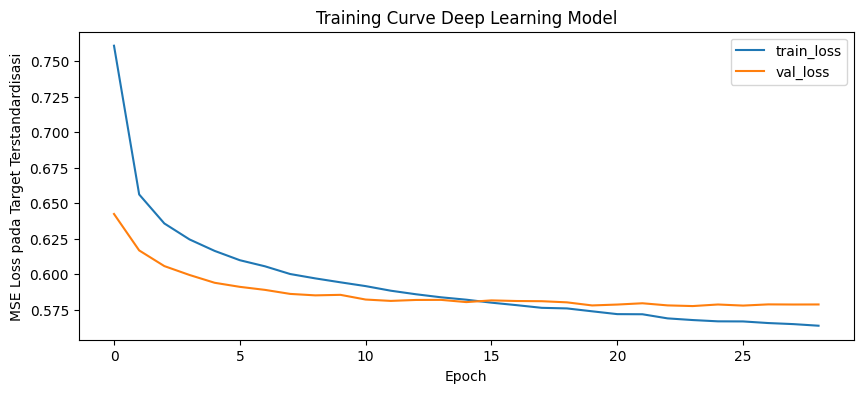

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.title("Training Curve Deep Learning Model")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss pada Target Terstandardisasi")
plt.legend()
plt.show()

## 26. Evaluasi Deep Learning Model

Output model deep learning masih berada pada skala target yang distandardisasi.

Karena itu, prediksi harus dikembalikan ke skala tahun asli:

```text
prediksi_tahun = prediksi_scaled * y_std + y_mean
```

Setelah itu metrik dihitung pada satuan tahun.

In [28]:
dl_val_pred_scaled = mlp_model.predict(X_val_scaled, batch_size=CONFIG["DL_BATCH_SIZE"]).ravel()
dl_test_pred_scaled = mlp_model.predict(X_test_scaled, batch_size=CONFIG["DL_BATCH_SIZE"]).ravel()

dl_val_pred = dl_val_pred_scaled * y_std + y_mean
dl_test_pred = dl_test_pred_scaled * y_std + y_mean

dl_val_metrics = regression_metrics(y_val, dl_val_pred)
dl_test_metrics = regression_metrics(y_test, dl_test_pred)

print_metrics("Deep Learning Validation Metrics", dl_val_metrics)
print()
print_metrics("Deep Learning Test Metrics", dl_test_metrics)

151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
151/151 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Deep Learning Validation Metrics
--------------------------------
MSE: 73.3565
RMSE: 8.5648
MAE: 5.8610
R2: 0.3826

Deep Learning Test Metrics
--------------------------
MSE: 73.5594
RMSE: 8.5767
MAE: 5.8563
R2: 0.3773


## 27. Log Deep Learning Model ke MLflow

Model deep learning, parameter training, dan metrik evaluasi dicatat ke MLflow.

In [29]:
with mlflow.start_run(run_name="deep_learning_mlp"):
  mlflow.log_params({
    "model_type": "TensorFlow/Keras MLP",
    "hidden_units": "128,64",
    "dropout_rate": 0.20,
    "learning_rate": 1e-3,
    "batch_size": CONFIG["DL_BATCH_SIZE"],
    "epochs_requested": CONFIG["DL_EPOCHS"],
    "epochs_trained": len(history.history["loss"]),
    "n_features": len(feature_cols)
  })
  mlflow.log_metrics({f"val_{k}": v for k, v in dl_val_metrics.items()})
  mlflow.log_metrics({f"test_{k}": v for k, v in dl_test_metrics.items()})
  mlflow.tensorflow.log_model(mlp_model, artifact_path="model")

print("Deep learning run selesai dicatat di MLflow.")

2026/06/17 12:01:45 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/17 12:01:45 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.


Deep learning run selesai dicatat di MLflow.


## 28. Perbandingan Model

Tabel ini membandingkan performa baseline, ML model, dan DL model pada test set.

Cara membaca hasil:

- RMSE dan MAE makin kecil makin baik.
- R² makin besar makin baik.
- Model final sebaiknya dipilih berdasarkan test MAE/RMSE, bukan hanya training performance.

Untuk kasus prediksi tahun lagu, model dengan MAE terkecil lebih mudah dijelaskan karena langsung berarti rata-rata error dalam satuan tahun.

In [30]:
comparison_df = pd.DataFrame([
  {"model": "Baseline Median", **baseline_test_metrics},
  {"model": "Tuned HistGradientBoosting", **ml_test_metrics},
  {"model": "Deep Learning MLP", **dl_test_metrics}
])

comparison_df = comparison_df.sort_values(by="mae", ascending=True).reset_index(drop=True)
display(comparison_df)

best_model_name = comparison_df.iloc[0]["model"]
print("Model terbaik berdasarkan Test MAE:", best_model_name)

,model,mse,rmse,mae,r2
0,Deep Learning MLP,73.559425,8.576679,5.856321,0.377279
1,Tuned HistGradientBoosting,79.400322,8.910686,6.233333,0.327832
2,Baseline Median,130.964508,11.443973,7.605754,-0.108687


Model terbaik berdasarkan Test MAE: Deep Learning MLP


## 29. Visualisasi Prediksi vs Aktual

Plot ini membandingkan tahun asli dan tahun prediksi.

Interpretasi:

- Titik yang dekat dengan garis diagonal berarti prediksi akurat.
- Titik yang jauh dari garis diagonal berarti prediksi meleset jauh.
- Jika banyak titik terkumpul pada rentang tertentu, model mungkin bias ke rentang tahun mayoritas.

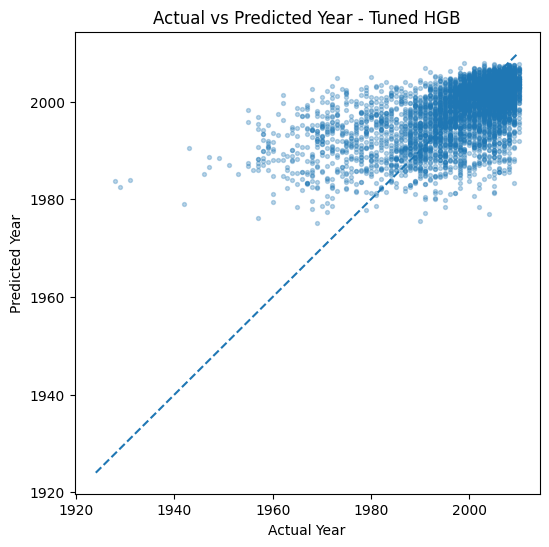

In [31]:
# Gunakan prediksi dari ML model karena model ini akan dipakai untuk LIME.
plot_sample_size = min(5000, len(y_test))
rng = np.random.default_rng(CONFIG["RANDOM_STATE"])
plot_idx = rng.choice(len(y_test), size=plot_sample_size, replace=False)

plt.figure(figsize=(6, 6))
plt.scatter(np.asarray(y_test)[plot_idx], np.asarray(ml_test_pred)[plot_idx], alpha=0.3, s=8)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")
plt.title("Actual vs Predicted Year - Tuned HGB")
plt.xlabel("Actual Year")
plt.ylabel("Predicted Year")
plt.show()

## 30. Residual Analysis

Residual adalah selisih antara nilai aktual dan prediksi.

```text
residual = actual - predicted
```

Jika residual menyebar acak di sekitar nol, model relatif stabil.
Jika residual memiliki pola tertentu, model mungkin bias pada tahun tertentu.

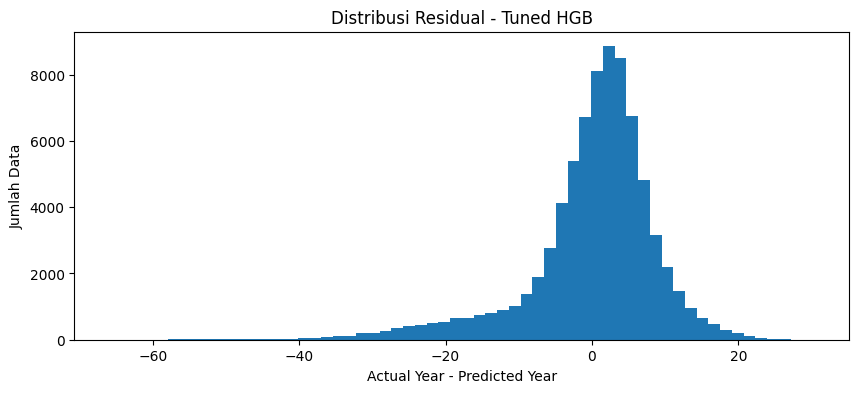

Rata-rata residual: 0.03455142534099697
Median residual: 1.4730688449723175
Std residual: 8.910618868126035


In [32]:
residuals = np.asarray(y_test) - np.asarray(ml_test_pred)

plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=60)
plt.title("Distribusi Residual - Tuned HGB")
plt.xlabel("Actual Year - Predicted Year")
plt.ylabel("Jumlah Data")
plt.show()

print("Rata-rata residual:", float(np.mean(residuals)))
print("Median residual:", float(np.median(residuals)))
print("Std residual:", float(np.std(residuals)))

## 31. Interpretasi Model dengan LIME

LIME digunakan untuk menjelaskan prediksi individual.

LIME menjawab pertanyaan:

> Untuk satu lagu tertentu, fitur apa yang paling mendorong prediksi model menjadi lebih tinggi atau lebih rendah?

Karena fitur dataset tidak memiliki nama domain asli, interpretasi hanya bisa dilakukan pada level `feature_1`, `feature_2`, dan seterusnya.

Makna kontribusi:

- Kontribusi positif: fitur tersebut mendorong prediksi ke tahun yang lebih baru.
- Kontribusi negatif: fitur tersebut mendorong prediksi ke tahun yang lebih lama.

Catatan penting: LIME menjelaskan prediksi lokal, bukan keseluruhan perilaku model secara global.

In [33]:
# LIME bisa berat jika memakai semua data training. Gunakan sample saja.
lime_sample_size = min(CONFIG["LIME_SAMPLE_SIZE"], len(X_train_imp))
rng = np.random.default_rng(CONFIG["RANDOM_STATE"])
lime_idx = rng.choice(len(X_train_imp), size=lime_sample_size, replace=False)

lime_train = X_train_imp[lime_idx]

explainer = lime.lime_tabular.LimeTabularExplainer(
  training_data=lime_train,
  feature_names=feature_cols,
  mode="regression",
  discretize_continuous=True,
  random_state=CONFIG["RANDOM_STATE"]
)

instance_index = 0
instance = X_test_imp[instance_index]
actual_year = float(np.asarray(y_test)[instance_index])
predicted_year = float(best_ml_model.predict(instance.reshape(1, -1))[0])

explanation = explainer.explain_instance(
  data_row=instance,
  predict_fn=lambda data: best_ml_model.predict(data),
  num_features=10
)

lime_df = pd.DataFrame(explanation.as_list(), columns=["fitur/kondisi", "kontribusi"])
lime_df["arah"] = np.where(
  lime_df["kontribusi"] >= 0,
  "menaikkan prediksi tahun",
  "menurunkan prediksi tahun"
)

print("Actual year:", actual_year)
print("Predicted year:", predicted_year)
display(lime_df)

Actual year: 2008.0
Predicted year: 2004.7656662666302


,fitur/kondisi,kontribusi,arah
0,feature_2 <= -25.87,3.402799,menaikkan prediksi tahun
1,feature_6 <= -18.55,2.388524,menaikkan prediksi tahun
2,39.89 < feature_1 <= 44.25,-1.858477,menurunkan prediksi tahun
3,feature_14 > 3066.89,1.501787,menaikkan prediksi tahun
4,feature_13 > 43.51,1.132028,menaikkan prediksi tahun
5,feature_85 > 8.41,0.932744,menaikkan prediksi tahun
6,-12.44 < feature_3 <= 9.91,0.780142,menaikkan prediksi tahun
7,feature_57 > 226.85,-0.751649,menurunkan prediksi tahun
8,feature_58 <= -117.49,-0.660069,menurunkan prediksi tahun
9,feature_39 > -57.49,0.596391,menaikkan prediksi tahun


## 32. Narasi Interpretasi LIME

Gunakan output tabel LIME di atas untuk menulis interpretasi singkat.

Contoh cara membaca:

- Jika `feature_12 > ...` memiliki kontribusi positif, maka kondisi tersebut membuat model memprediksi lagu lebih baru.
- Jika `feature_5 <= ...` memiliki kontribusi negatif, maka kondisi tersebut membuat model memprediksi lagu lebih lama.

Karena fitur tidak memiliki nama asli, interpretasi tidak boleh mengklaim makna audio tertentu seperti tempo, pitch, atau genre kecuali dokumentasi dataset memang menyediakannya.

In [34]:
top_positive = lime_df.sort_values("kontribusi", ascending=False).head(3)
top_negative = lime_df.sort_values("kontribusi", ascending=True).head(3)

print("Ringkasan interpretasi otomatis:")
print(f"Model memprediksi lagu ini rilis sekitar tahun {predicted_year:.1f}, sedangkan tahun aktualnya {actual_year:.0f}.")
print("\nFitur yang paling menaikkan prediksi tahun:")
display(top_positive)
print("\nFitur yang paling menurunkan prediksi tahun:")
display(top_negative)

Ringkasan interpretasi otomatis:
Model memprediksi lagu ini rilis sekitar tahun 2004.8, sedangkan tahun aktualnya 2008.

Fitur yang paling menaikkan prediksi tahun:


,fitur/kondisi,kontribusi,arah
0,feature_2 <= -25.87,3.402799,menaikkan prediksi tahun
1,feature_6 <= -18.55,2.388524,menaikkan prediksi tahun
3,feature_14 > 3066.89,1.501787,menaikkan prediksi tahun



Fitur yang paling menurunkan prediksi tahun:


,fitur/kondisi,kontribusi,arah
2,39.89 < feature_1 <= 44.25,-1.858477,menurunkan prediksi tahun
7,feature_57 > 226.85,-0.751649,menurunkan prediksi tahun
8,feature_58 <= -117.49,-0.660069,menurunkan prediksi tahun


## 33. Simpan Artifact Final

Artifact yang disimpan:

- model machine learning terbaik,
- imputer,
- scaler,
- batas clipping,
- daftar fitur,
- model deep learning,
- tabel metrik,
- ringkasan konfigurasi.

File ini berguna agar model bisa dipakai ulang tanpa melatih dari awal.

In [35]:
artifact_dir = Path(CONFIG["ARTIFACT_DIR"])
artifact_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_ml_model, artifact_dir / "best_hgb_model.joblib")
joblib.dump(imputer, artifact_dir / "median_imputer.joblib")
joblib.dump(scaler, artifact_dir / "standard_scaler.joblib")

preprocessing_metadata = {
  "feature_cols": feature_cols,
  "clip_lower": clip_lower.to_dict(),
  "clip_upper": clip_upper.to_dict(),
  "target_mean": y_mean,
  "target_std": y_std,
  "config": CONFIG
}

with open(artifact_dir / "preprocessing_metadata.json", "w") as f:
  json.dump(preprocessing_metadata, f, indent=2)

comparison_df.to_csv(artifact_dir / "model_comparison_metrics.csv", index=False)

mlp_model.save(artifact_dir / "deep_learning_mlp.keras")

print("Artifact tersimpan di:", artifact_dir)
print(os.listdir(artifact_dir))

Artifact tersimpan di: /content/song_year_artifacts
['model_comparison_metrics.csv', 'median_imputer.joblib', 'preprocessing_metadata.json', 'best_hgb_model.joblib', 'deep_learning_mlp.keras', 'standard_scaler.joblib']


## 34. Buat ZIP Artifact

ZIP ini bisa diunduh dari panel file Colab sebagai bukti hasil training dan artifact model.

In [36]:
zip_path = shutil.make_archive(
  base_name="/content/song_year_artifacts",
  format="zip",
  root_dir=artifact_dir
)

print("ZIP artifact dibuat:", zip_path)

ZIP artifact dibuat: /content/song_year_artifacts.zip


## 35. Kesimpulan

Template kesimpulan yang bisa kamu sesuaikan setelah notebook dijalankan:

1. Dataset berhasil dibaca dengan benar menggunakan `header=None` karena file tidak memiliki nama kolom.
2. Target `year` dipisahkan dari fitur numerik audio.
3. Data dibersihkan melalui validasi target, filtering fitur dengan missing value tinggi, penghapusan fitur konstan, median imputation, dan quantile clipping untuk outlier.
4. Baseline model digunakan sebagai pembanding awal.
5. Model machine learning `HistGradientBoostingRegressor` dituning menggunakan Optuna.
6. Model deep learning MLP dilatih menggunakan TensorFlow/Keras dengan standardisasi fitur dan target.
7. Evaluasi dilakukan menggunakan MSE, RMSE, MAE, dan R².
8. MLflow digunakan untuk tracking eksperimen sehingga parameter, metrik, dan model dapat dibandingkan.
9. LIME digunakan untuk menjelaskan prediksi individual, meskipun interpretasi terbatas karena fitur tidak memiliki nama domain yang human-friendly.

Kesimpulan utama sebaiknya ditulis berdasarkan model dengan **test MAE terendah**.

## 36. Cara Membuka MLflow UI di Colab

MLflow sudah mencatat eksperimen ke database SQLite lokal:

```text
/content/mlflow_song_year.db
```

Untuk melihat UI MLflow di Colab, kamu bisa menjalankan command berikut secara manual di cell baru:

```python
!mlflow ui --backend-store-uri sqlite:////content/mlflow_song_year.db --host 0.0.0.0 --port 5000
```

Namun cell tersebut akan terus berjalan karena membuka server. Jadi jangan dimasukkan ke proses `Run all` jika kamu hanya ingin mengeksekusi notebook sampai selesai.